In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('final_dataset.csv')

In [3]:
# First 5 sample rows of Dataset
df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
# Name of columns
list(df.columns)

['index',
 'having_IPhaving_IP_Address',
 'URLURL_Length',
 'Shortining_Service',
 'having_At_Symbol',
 'double_slash_redirecting',
 'Prefix_Suffix',
 'having_Sub_Domain',
 'SSLfinal_State',
 'Domain_registeration_length',
 'Favicon',
 'port',
 'HTTPS_token',
 'Request_URL',
 'URL_of_Anchor',
 'Links_in_tags',
 'SFH',
 'Submitting_to_email',
 'Abnormal_URL',
 'Redirect',
 'on_mouseover',
 'RightClick',
 'popUpWidnow',
 'Iframe',
 'age_of_domain',
 'DNSRecord',
 'web_traffic',
 'Page_Rank',
 'Google_Index',
 'Links_pointing_to_page',
 'Statistical_report',
 'Result']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   index                        11055 non-null  int64
 1   having_IPhaving_IP_Address   11055 non-null  int64
 2   URLURL_Length                11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [6]:
for col in df.columns:
    unique_value_list = df[col].unique()
    if len(unique_value_list) > 10:
        print(f'{col} has {df[col].nunique()} unique values')
    else:
        print(f'{col} contains:\t\t\t{unique_value_list}')

index has 11055 unique values
having_IPhaving_IP_Address contains:			[-1  1]
URLURL_Length contains:			[ 1  0 -1]
Shortining_Service contains:			[ 1 -1]
having_At_Symbol contains:			[ 1 -1]
double_slash_redirecting contains:			[-1  1]
Prefix_Suffix contains:			[-1  1]
having_Sub_Domain contains:			[-1  0  1]
SSLfinal_State contains:			[-1  1  0]
Domain_registeration_length contains:			[-1  1]
Favicon contains:			[ 1 -1]
port contains:			[ 1 -1]
HTTPS_token contains:			[-1  1]
Request_URL contains:			[ 1 -1]
URL_of_Anchor contains:			[-1  0  1]
Links_in_tags contains:			[ 1 -1  0]
SFH contains:			[-1  1  0]
Submitting_to_email contains:			[-1  1]
Abnormal_URL contains:			[-1  1]
Redirect contains:			[0 1]
on_mouseover contains:			[ 1 -1]
RightClick contains:			[ 1 -1]
popUpWidnow contains:			[ 1 -1]
Iframe contains:			[ 1 -1]
age_of_domain contains:			[-1  1]
DNSRecord contains:			[-1  1]
web_traffic contains:			[-1  0  1]
Page_Rank contains:			[-1  1]
Google_Index contains:			[ 1 -1]
L

According to the Data descrition, these are the meaning of the values in the data
* 1 means legitimate
* 0 is suspicious
* -1 is phishing

In [7]:
df = df.drop(columns=['index'])

Result
 1    6157
-1    4898
Name: count, dtype: int64


<Axes: xlabel='Result', ylabel='count'>

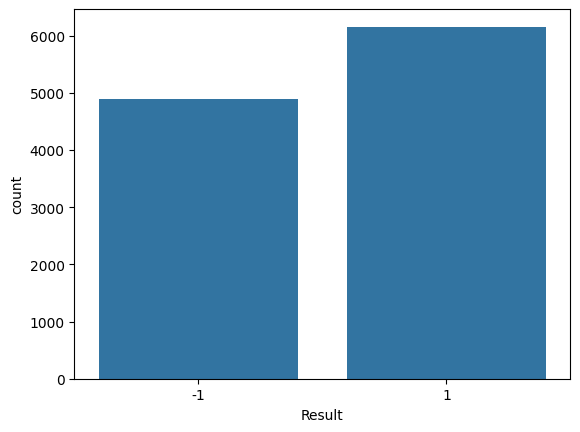

In [9]:
print(df['Result'].value_counts())
#plotting the distribution of the target variable
sns.countplot(x='Result', data=df)

In [15]:
# Profile 

from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Phishing URL Dataset Profile Report Final", explorative=True)
profile.to_file("phishing_url_profile_report_final.html")


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 113.59it/s]


<Axes: >

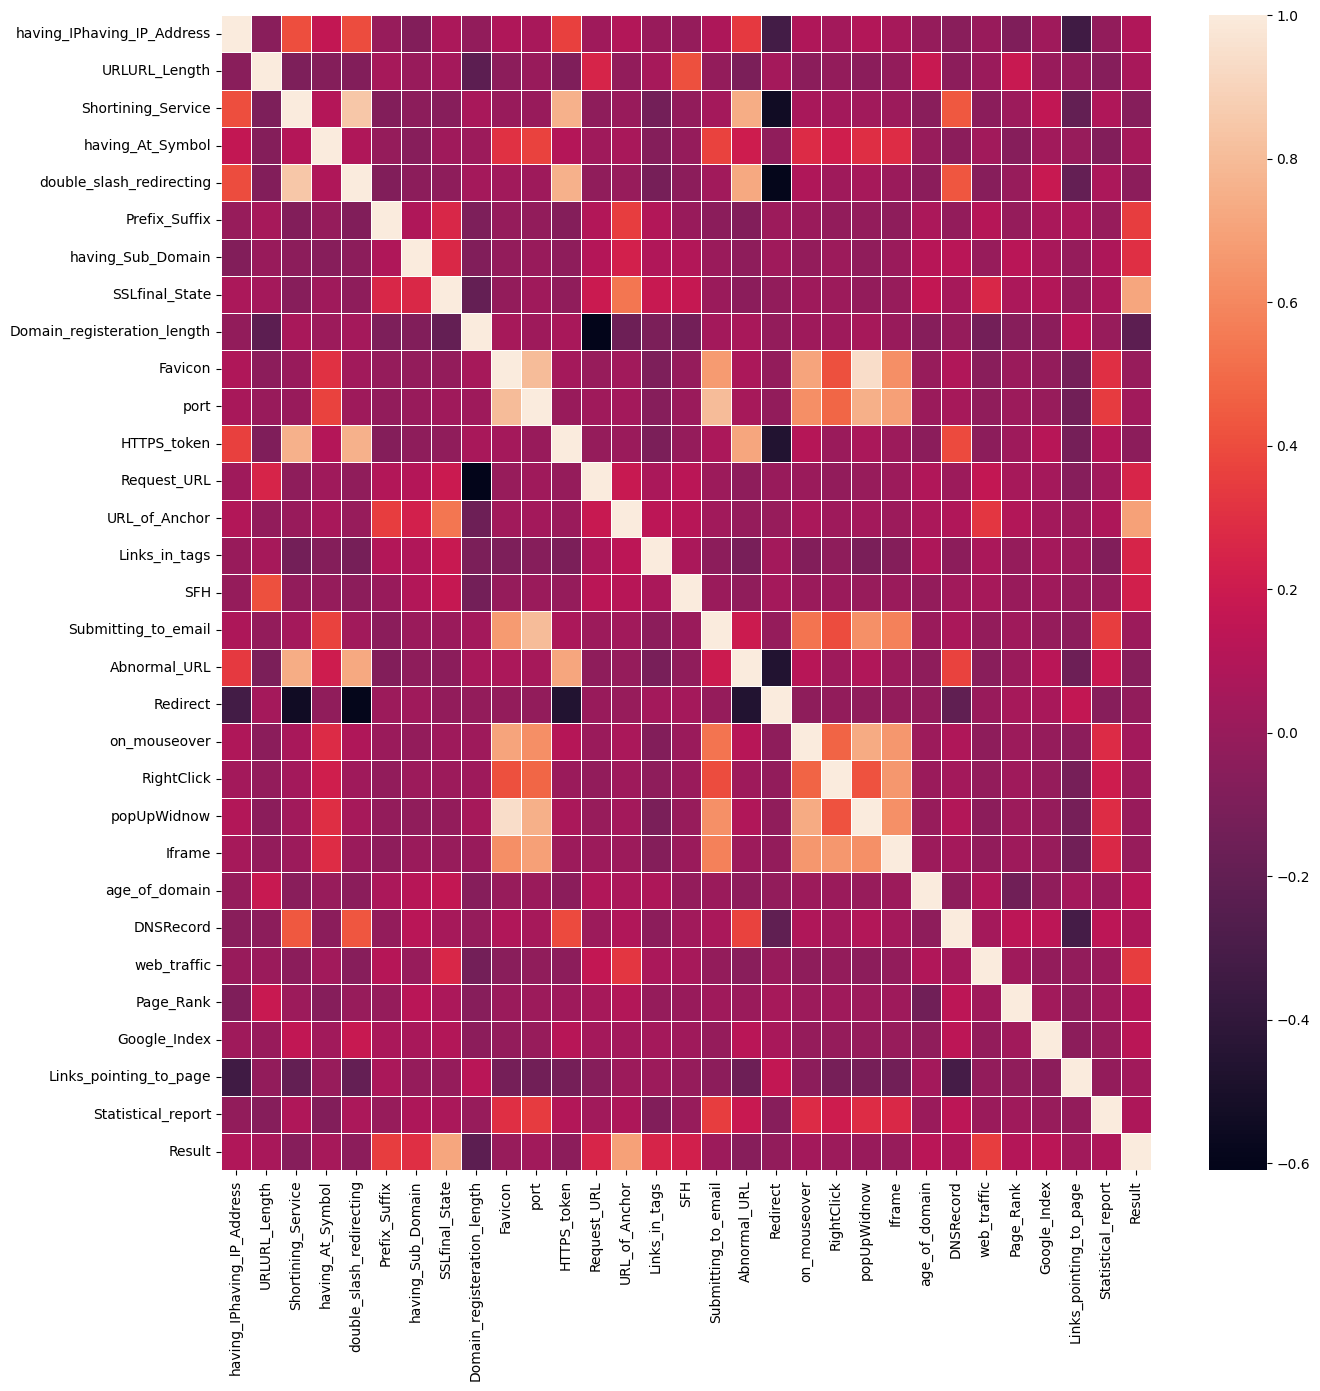

In [10]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), linewidths=.5)

In [13]:
#Dropping popupwindow column
df = df.drop(columns=['popUpWidnow'])

In [16]:
#Feature Selection using mutual information
from sklearn.feature_selection import mutual_info_classif
X = df.drop(columns=['Result'])
y = df['Result']
mutual_info = mutual_info_classif(X, y)
mutual_info_series = pd.Series(mutual_info, index=X.columns)
mutual_info_series.sort_values(ascending=False, inplace=True)
print(mutual_info_series)

SSLfinal_State                 0.349963
URL_of_Anchor                  0.331514
Prefix_Suffix                  0.085254
web_traffic                    0.080608
having_Sub_Domain              0.076239
Request_URL                    0.040360
SFH                            0.028850
Links_in_tags                  0.026847
Domain_registeration_length    0.025080
Links_pointing_to_page         0.012965
HTTPS_token                    0.007587
Google_Index                   0.007581
having_At_Symbol               0.006136
Statistical_report             0.006121
Favicon                        0.005837
age_of_domain                  0.005582
Iframe                         0.004929
Page_Rank                      0.004525
on_mouseover                   0.003939
RightClick                     0.002783
Abnormal_URL                   0.002334
Shortining_Service             0.001515
port                           0.000101
double_slash_redirecting       0.000000
having_IPhaving_IP_Address     0.000000


In [17]:
#Selecting top 23 features based on mutual information
top_features = mutual_info_series.head(23).index
X_selected = X[top_features]


In [20]:
#train test split
y_xgb = y.map({-1: 0, 1: 1})
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_xgb, test_size=0.2, random_state=42)


In [21]:
#Model Training (Logistic Regression, Decision Tree, Random Forest, Adaboost, Xgboost,) and Cross Validation
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier()
}
for name, model in models.items():
    scores = cross_val_score(model, X_selected, y_xgb, cv=5)
    print(f'{name} Cross Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')
    

Logistic Regression Cross Validation Accuracy: 0.9152 ± 0.0056
Decision Tree Cross Validation Accuracy: 0.9508 ± 0.0289
Random Forest Cross Validation Accuracy: 0.9619 ± 0.0154
AdaBoost Cross Validation Accuracy: 0.9304 ± 0.0058
XGBoost Cross Validation Accuracy: 0.9584 ± 0.0145


In [22]:
# Train models and collect predictions for evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    # Cross-validation accuracy
    cv_scores = cross_val_score(model, X_selected, y_xgb, cv=5, scoring='accuracy')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'report': report,
        'cm': cm,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f'\n{"-"*60}')
    print(f'Model: {name}')
    print(f'Test Accuracy: {acc:.4f}')
    print(f'Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Phishing (-1)', 'Legitimate (1)']))



------------------------------------------------------------
Model: Logistic Regression
Test Accuracy: 0.9177
Cross-Validation Accuracy: 0.9152 ± 0.0056

Classification Report:
                precision    recall  f1-score   support

 Phishing (-1)       0.92      0.89      0.90       956
Legitimate (1)       0.92      0.94      0.93      1255

      accuracy                           0.92      2211
     macro avg       0.92      0.91      0.92      2211
  weighted avg       0.92      0.92      0.92      2211


------------------------------------------------------------
Model: Decision Tree
Test Accuracy: 0.9557
Cross-Validation Accuracy: 0.9498 ± 0.0307

Classification Report:
                precision    recall  f1-score   support

 Phishing (-1)       0.95      0.95      0.95       956
Legitimate (1)       0.96      0.96      0.96      1255

      accuracy                           0.96      2211
     macro avg       0.96      0.95      0.95      2211
  weighted avg       0.96    

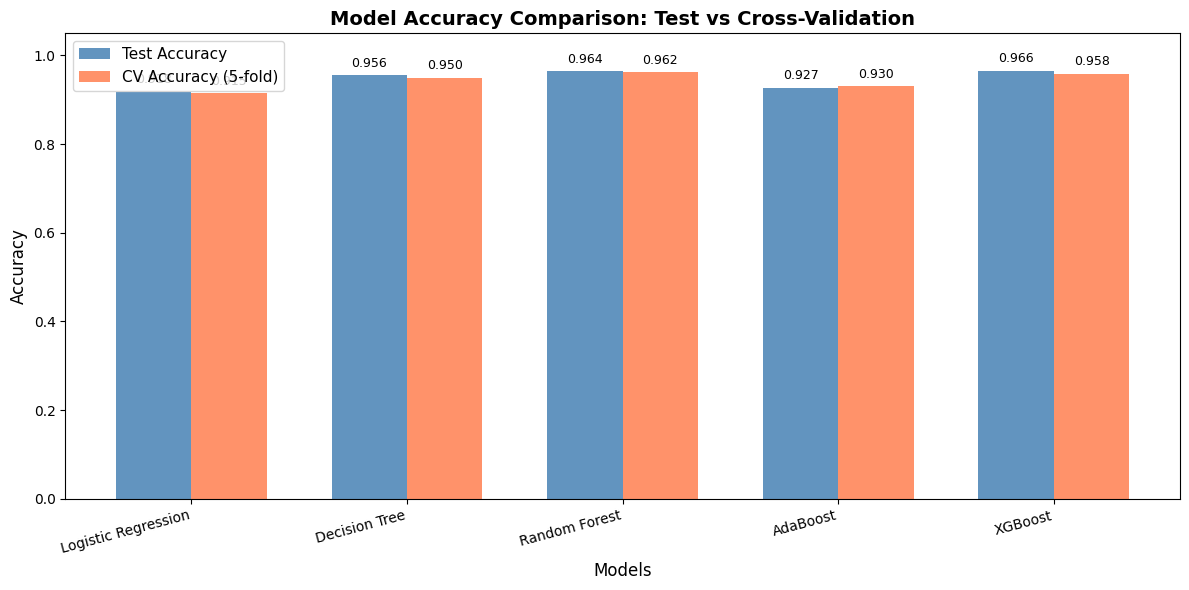

In [23]:
# Accuracy Comparison Chart 
model_names = list(results.keys())
test_accs   = [results[n]['accuracy']  for n in model_names]
cv_accs     = [results[n]['cv_mean']   for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, cv_accs,   width, label='CV Accuracy (5-fold)', color='coral', alpha=0.85)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison: Test vs Cross-Validation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


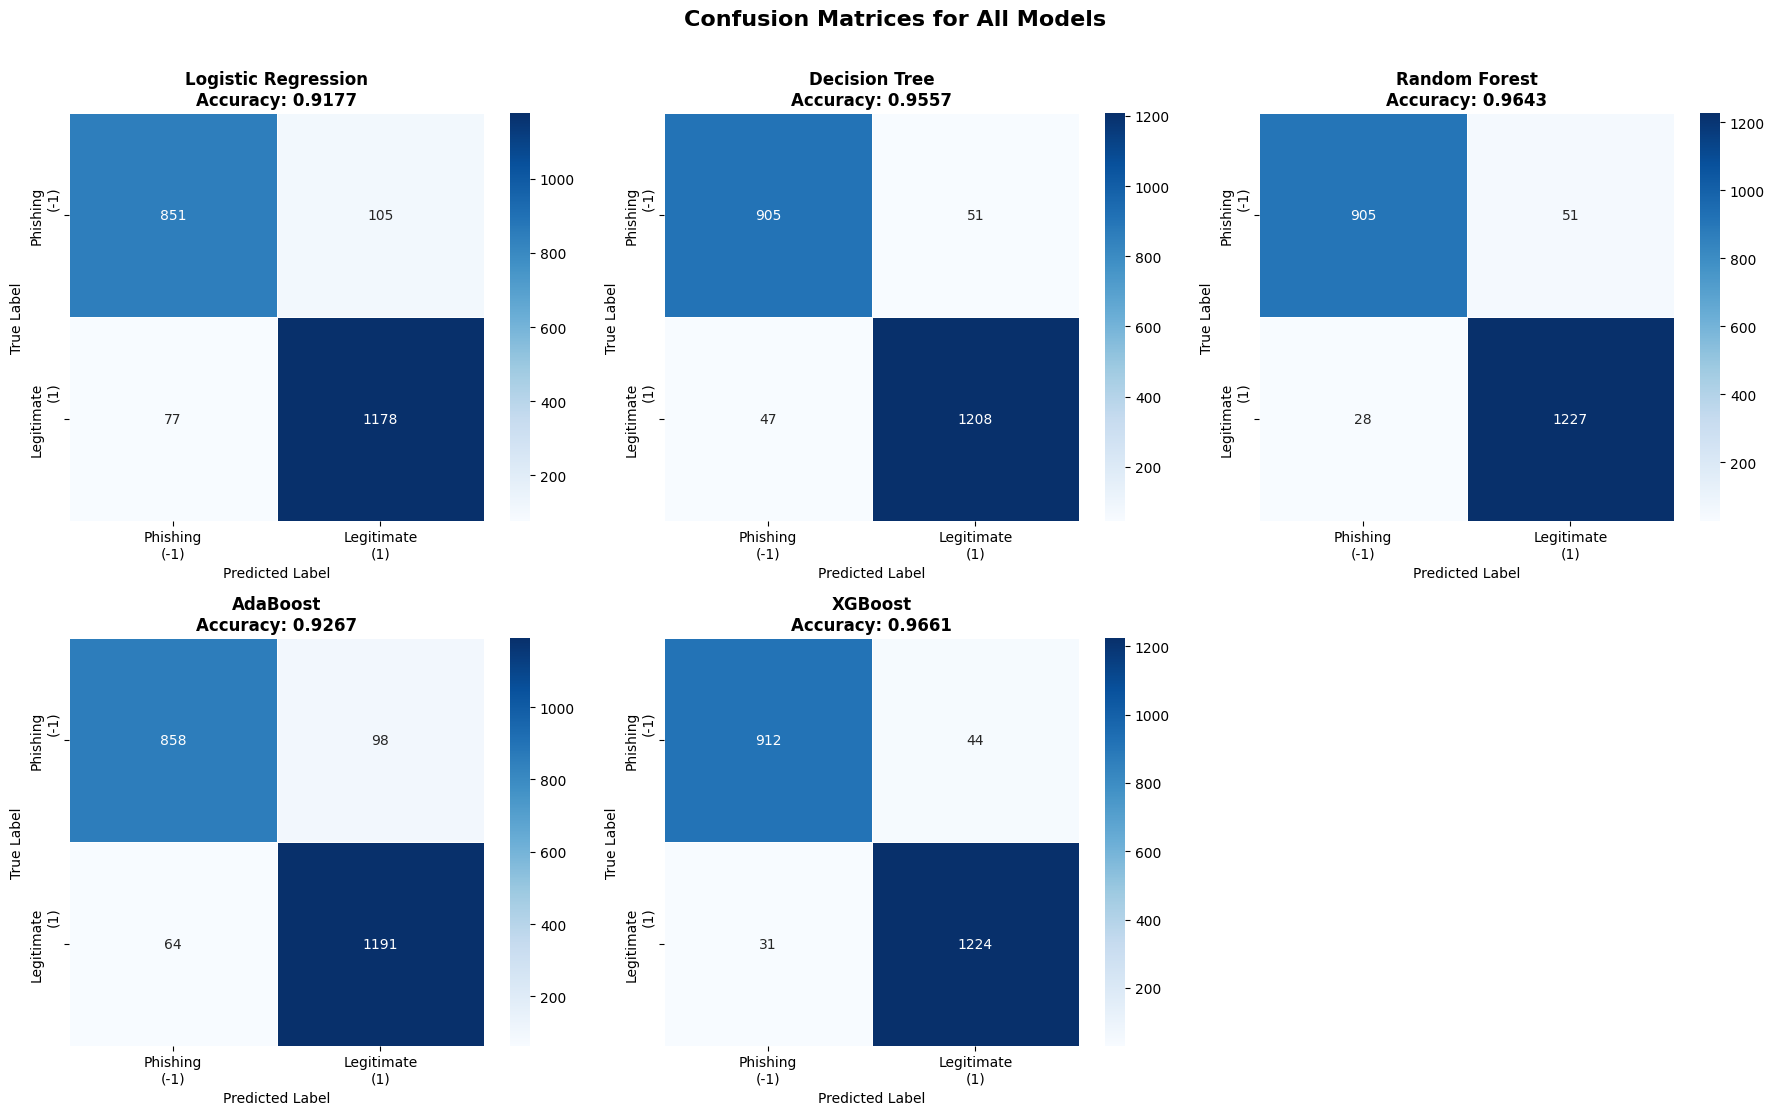

In [24]:
# Confusion Matrices 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

class_labels = ['Phishing\n(-1)', 'Legitimate\n(1)']

for i, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, cbar=True)
    axes[i].set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

# Hide the extra subplot
if len(results) < len(axes):
    for j in range(len(results), len(axes)):
        axes[j].set_visible(False)

fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


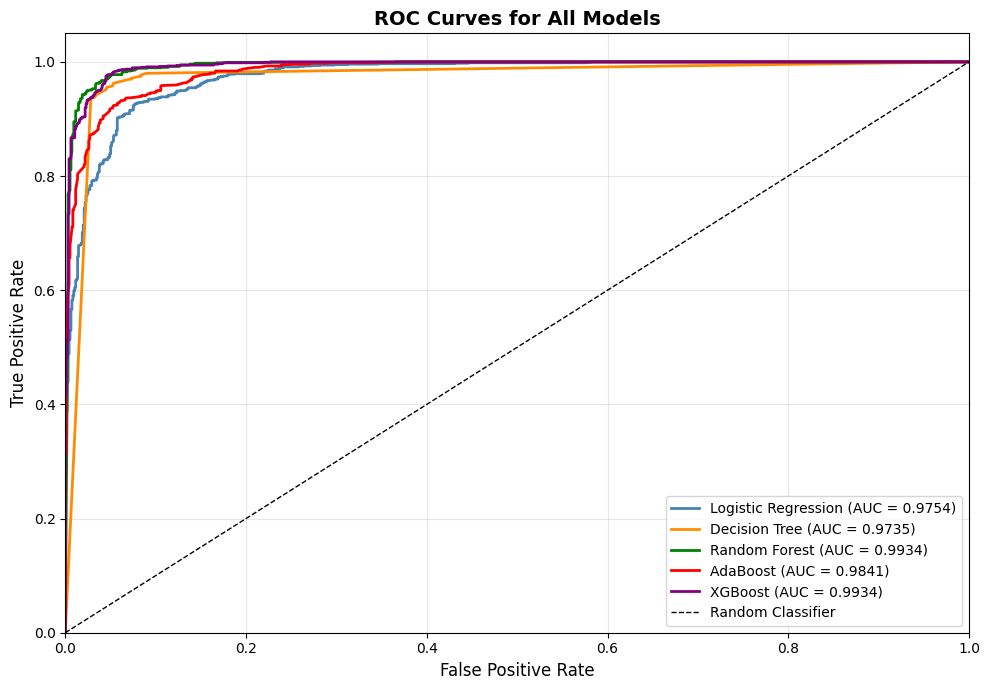

In [25]:
# ROC Curves 
from sklearn.metrics import roc_curve, auc

# Map labels: -1 → 0, 1 → 1  (roc_curve needs binary 0/1)
y_test_bin = (y_test == 1).astype(int)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for (name, res), color in zip(results.items(), colors):
    model = res['model']
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


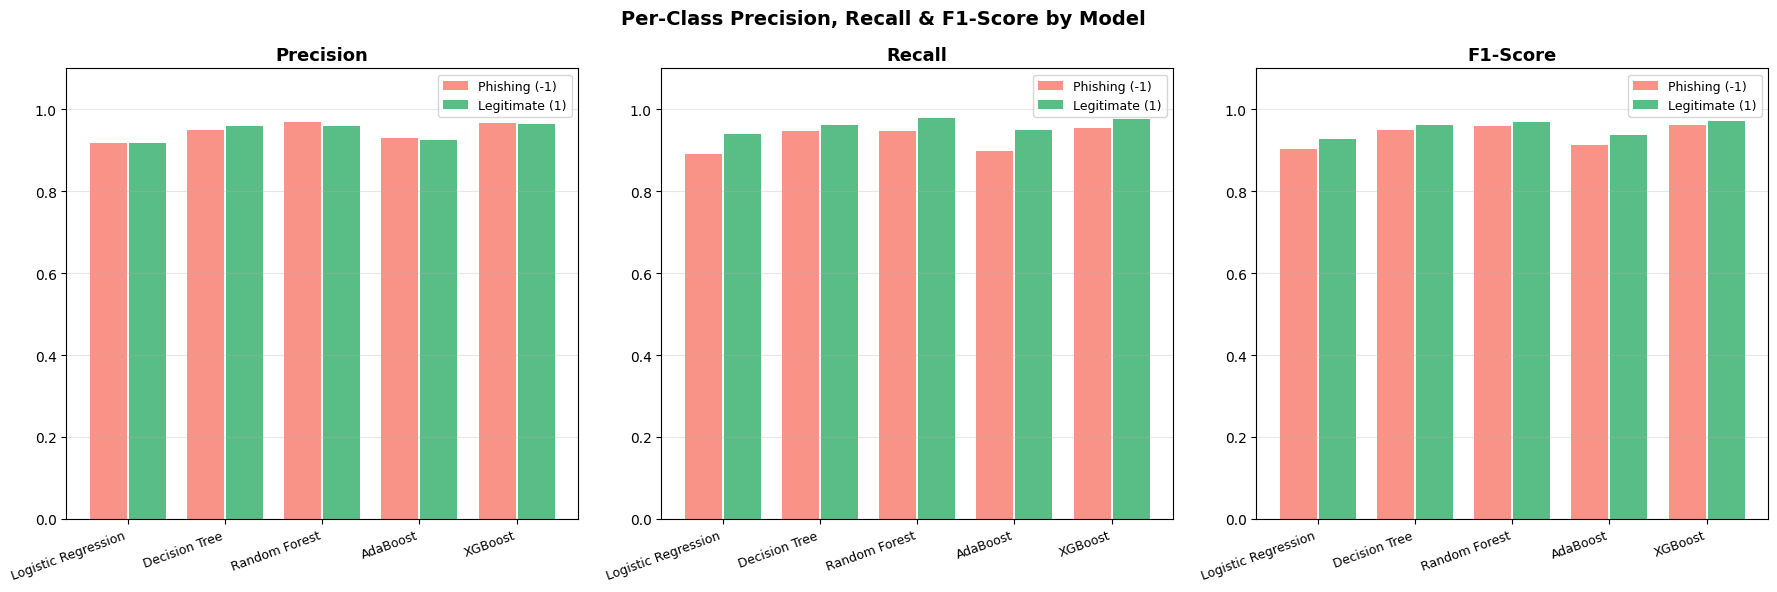

In [27]:
# Precision, Recall, F1 Comparison
metrics_data = []
for name, res in results.items():
    rpt = res['report']
    for cls_key, label in [('0', 'Phishing'), ('1', 'Legitimate')]:
        metrics_data.append({
            'Model': name,
            'Class': label,
            'Precision': rpt[cls_key]['precision'],
            'Recall':    rpt[cls_key]['recall'],
            'F1-Score':  rpt[cls_key]['f1-score']
        })

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
metric_cols = ['Precision', 'Recall', 'F1-Score']

for ax, metric in zip(axes, metric_cols):
    phishing_vals   = metrics_df[metrics_df['Class'] == 'Phishing'][metric].values
    legitimate_vals = metrics_df[metrics_df['Class'] == 'Legitimate'][metric].values
    mdl_names       = metrics_df[metrics_df['Class'] == 'Phishing']['Model'].values

    x = np.arange(len(mdl_names))
    bars1 = ax.bar(x - 0.2, phishing_vals,   0.38, label='Phishing (-1)',   color='salmon',    alpha=0.85)
    bars2 = ax.bar(x + 0.2, legitimate_vals, 0.38, label='Legitimate (1)', color='mediumseagreen', alpha=0.85)

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(mdl_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Per-Class Precision, Recall & F1-Score by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


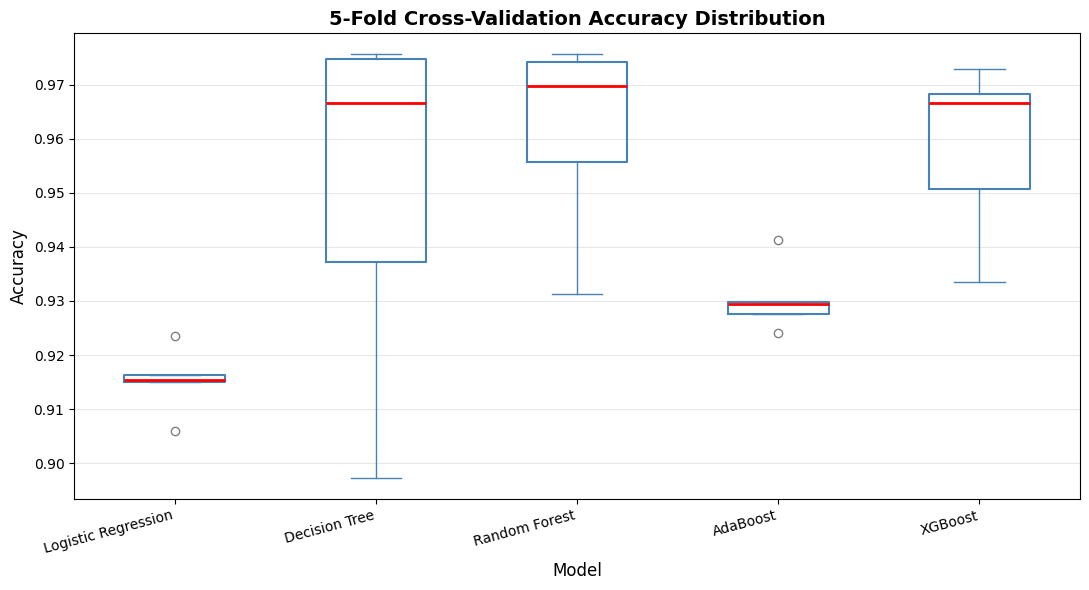

In [28]:
# Cross-Validation Score Distribution 
cv_all_scores = {}
for name, model_obj in models.items():
    cv_all_scores[name] = cross_val_score(model_obj, X_selected, y_xgb, cv=5, scoring='accuracy')

cv_df = pd.DataFrame(cv_all_scores)

fig, ax = plt.subplots(figsize=(11, 6))
cv_df.boxplot(ax=ax, grid=False,
              boxprops=dict(color='steelblue', linewidth=1.5),
              medianprops=dict(color='red', linewidth=2),
              whiskerprops=dict(color='steelblue'),
              capprops=dict(color='steelblue'),
              flierprops=dict(marker='o', color='gray', alpha=0.5))
ax.set_title('5-Fold Cross-Validation Accuracy Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_xticklabels(list(cv_all_scores.keys()), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


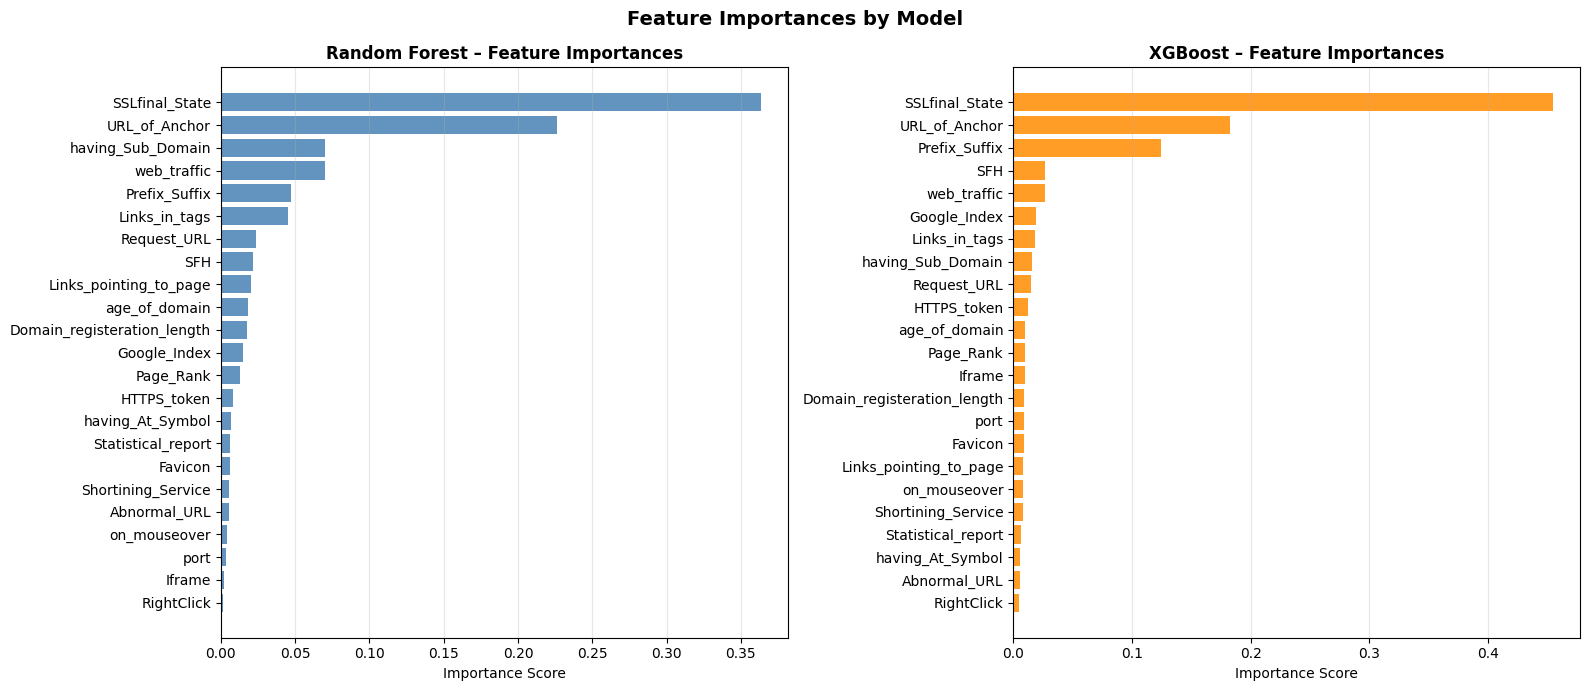

In [29]:
#  Feature Importance (Random Forest & XGBoost) 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, mdl_name in zip(axes, ['Random Forest', 'XGBoost']):
    model_obj   = results[mdl_name]['model']
    importances = model_obj.feature_importances_
    feat_names  = list(X_selected.columns)

    # Sort descending
    sorted_idx  = np.argsort(importances)[::-1]
    sorted_imp  = importances[sorted_idx]
    sorted_feat = [feat_names[i] for i in sorted_idx]

    bars = ax.barh(sorted_feat[::-1], sorted_imp[::-1],
                   color='steelblue' if mdl_name == 'Random Forest' else 'darkorange',
                   alpha=0.85)
    ax.set_title(f'{mdl_name} – Feature Importances', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importances by Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
